In [19]:
import cv2
import nibabel as nib
import pandas as pd
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt
import torch
import glob
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose, 
    ResizeWithPadOrCropd,
    EnsureChannelFirstd,
    NormalizeIntensityd
)
from sklearn.model_selection import train_test_split

In [20]:
description = pd.read_csv("../data/train_series_descriptions.csv")

In [21]:
description.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [22]:
path = "../../TotalSpineSeg"
vol_paths = glob.glob(path + "/data/sub*T2w.nii.gz") #os.listdir(path + "/data")
# vol_paths = glob.glob(path + "/data/sub*T1w.nii.gz") #os.listdir(path + "/data")


# y = "sub-4646740_acq-sag_rec-3666319702_T2w.nii.gz" 
y = np.random.choice(vol_paths).split("/")[-1]
# y = "sub-52397721_acq-sag_rec-2452297573_T2w.nii.gz"
x = y[:-7]
x = x+"_0000.nii.gz"

vol = nib.load(path+"/output/input/"+x).get_fdata()
seg = nib.load(path+"/output/step2_output/"+y).get_fdata()


# seg_path = "../../TotalSpineSeg/output/step2_output/sub-3637444890_acq-sag_rec-3892989905_T2w.nii.gz"
# vol_path =  "../../TotalSpineSeg/output/input/sub-3637444890_acq-sag_rec-3892989905_T2w_0000.nii.gz"

# vol = nib.load(vol_path).get_fdata()
# seg = nib.load(seg_path).get_fdata()


print("subj :", y)

## TODO ##

# split sagittal T1 volumes into left-right subvolumes
# create a dataset for foraminal narrowing
# for this end, check images orientation

subj : sub-2768000694_acq-sag_rec-582870174_T2w.nii.gz


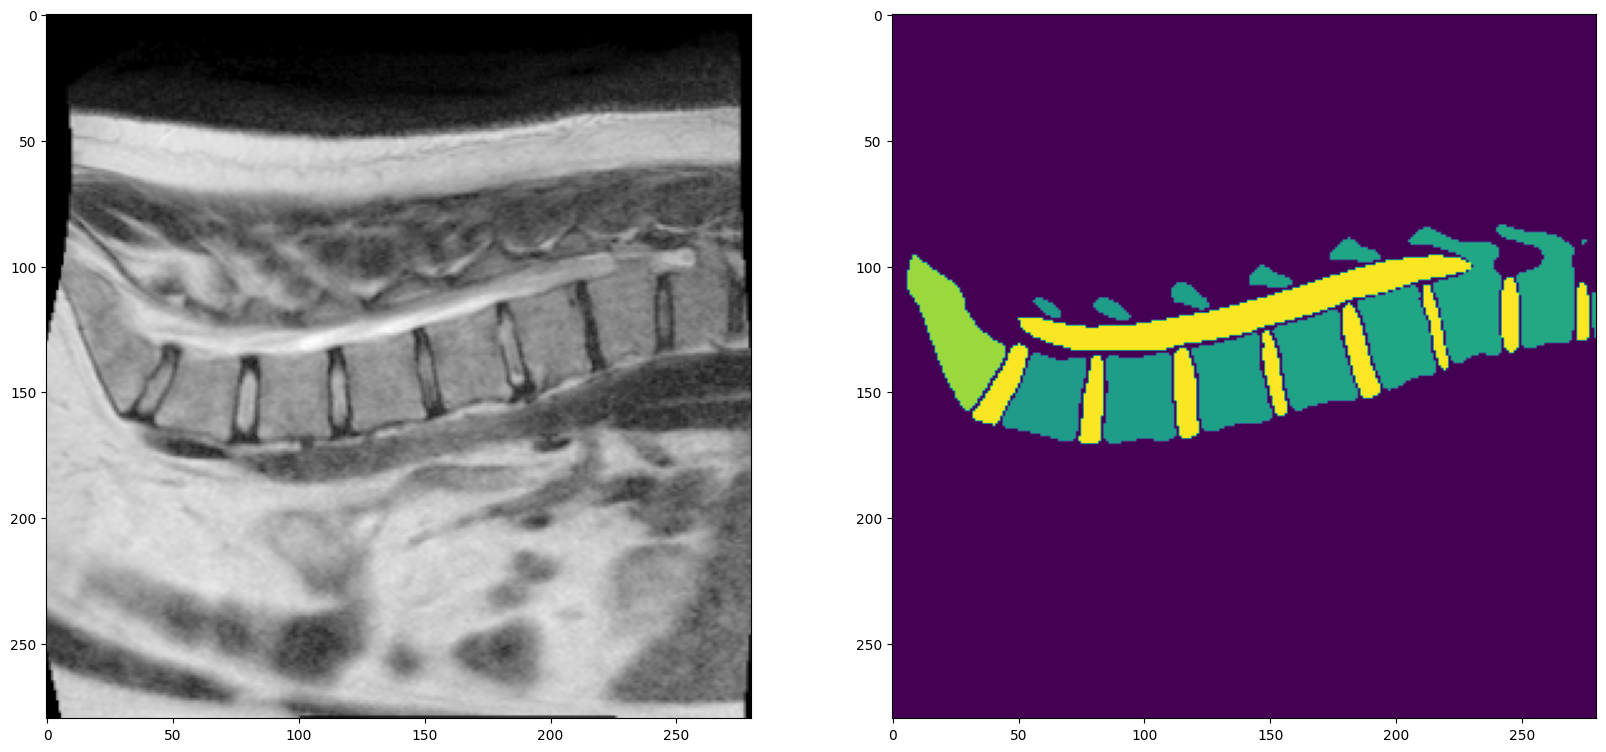

In [70]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=2)
ax[0].imshow(vol[40]**.5, cmap="gray")
ax[1].imshow(np.log(seg[40]+1))
plt.show()

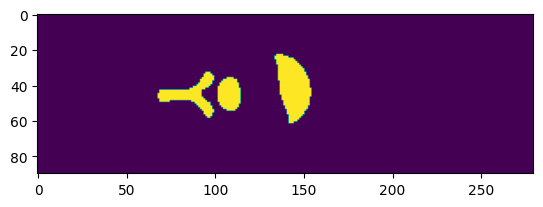

In [24]:
mask = np.isin(seg, [201, 202, 203, 204, 205, 200, 92, 18, 19, 20, 21, 22]).astype(int)
plt.imshow(mask[:,:,180])

In [25]:
discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
disc_l5 = np.isin(seg, [202]).astype(int)
disc_l4 = np.isin(seg, [203]).astype(int)
disc_l3 = np.isin(seg, [204]).astype(int)
disc_l2 = np.isin(seg, [205]).astype(int)
disc_l1 = np.isin(seg, [206]).astype(int)

In [26]:
np.unique(seg)

array([  0.,  18.,  19.,  20.,  21.,  22.,  23.,  24.,  25.,  92., 200.,
       201., 202., 203., 204., 205., 206., 207., 208., 209.])

In [27]:
def patch_extraction(vol, mask, d=0, h=20, w=20):
    """
    Extract a ROI from a volume with a given segmentation mask.

    vol : array of shape (D, H, W)
    mask : segmentation mask of shape (D, H, W)
    d, h, w : margin for each image axis
    """
    
    D, H, W = vol.shape
    mask = torch.Tensor(mask)
    nonzero_indices = torch.nonzero(mask)  # Extracting non-zero indices from the first channel

    d_min, h_min, w_min = nonzero_indices.min(0)[0]  # Minimum indices
    d_max, h_max, w_max = nonzero_indices.max(0)[0]  # Maximum indices
    
    patch = vol[max(0, d_min-d):min(D, d_max + d), 
                max(0, h_min - h):min(H, h_max + h), 
                max(0, w_min - w):min(W, w_max + w)]

    return patch

(45, 79, 55)
(43, 75, 50)
(47, 75, 50)
(46, 75, 50)
(46, 73, 63)


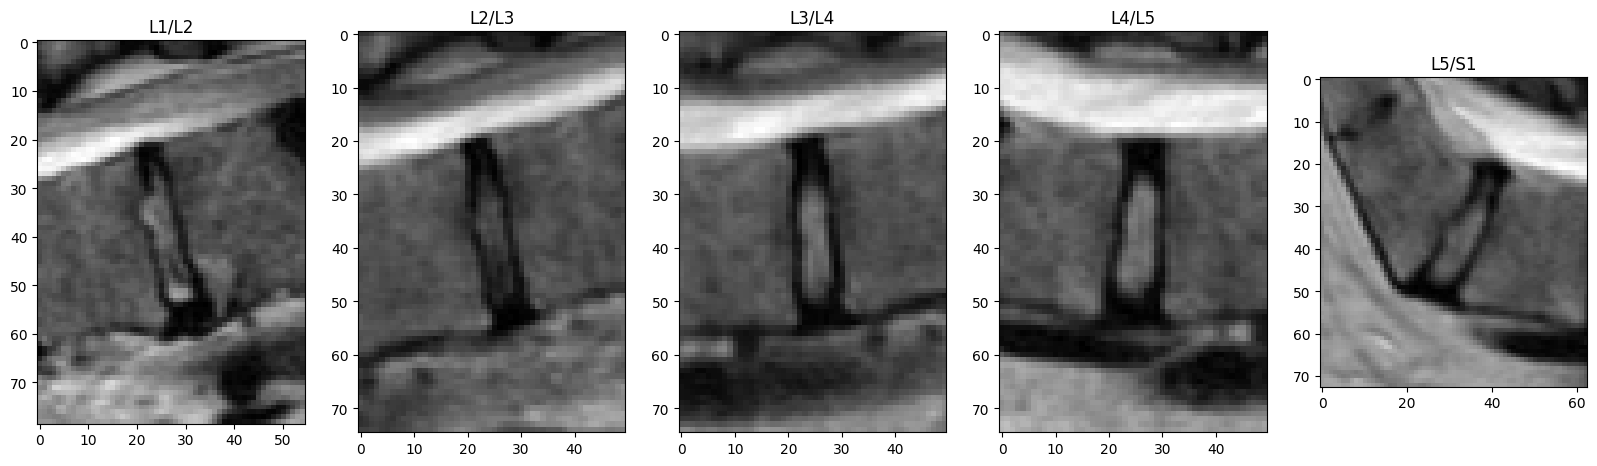

In [28]:
discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
disc_l5 = np.isin(seg, [202]).astype(int)
disc_l4 = np.isin(seg, [203]).astype(int)
disc_l3 = np.isin(seg, [204]).astype(int)
disc_l2 = np.isin(seg, [205]).astype(int)
disc_l1 = np.isin(seg, [206]).astype(int)

discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

fig, ax = plt.subplots(ncols=5, figsize=(20, 10))

D, H, W = vol.shape

for i, disc in enumerate(discs):

    patch = patch_extraction(vol, disc, d=0, h=20, w=20)
    print(patch.shape)
    d, h, w = patch.shape
    ax[i].imshow(patch[d//2], cmap="gray")
    ax[i].set_title(levels[i])

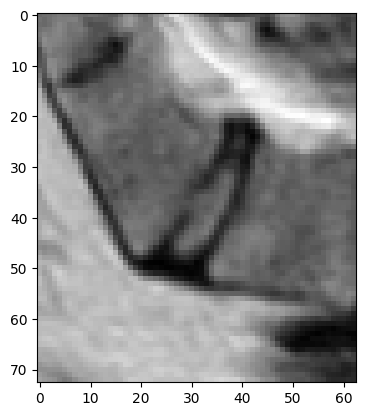

In [29]:
plt.imshow(patch[30,:,:], cmap="gray")
plt.show()

In [42]:
class SpinalCanalStenosisDataset(Dataset):
    def __init__(self, 
                 vol_paths : list = None,
                 seg_paths : list = None,
                 labels_csv : str = "../data/train.csv",
                 transform : any = None):
        
        
        text2int = {"Normal/Mild": 0, "Moderate": 1, "Severe": 2}
        vol_paths.sort()
        seg_paths.sort()
        self.vol_paths = vol_paths
        self.seg_paths = seg_paths
        self.transform = transform
        
        self.labels = pd.read_csv(labels_csv)
        self.labels = self.labels[["study_id",
                                   "spinal_canal_stenosis_l1_l2",
                                   "spinal_canal_stenosis_l2_l3",
                                   "spinal_canal_stenosis_l3_l4",
                                   "spinal_canal_stenosis_l4_l5",
                                   "spinal_canal_stenosis_l5_s1"]]
        self.labels = self.labels.replace(text2int)
        
    def __len__(self):
        return len(self.vol_paths)
        
    def __getitem__(self, idx):
        
        vol_path = self.vol_paths[idx]
        x = vol_path.split("/")[-1]
        x = x[:-7]+"_0000.nii.gz"
        
        vol = nib.load(path+"/output/input/"+x).get_fdata()
        
        study_id = x.split("_")[0][4:]
        
        seg_path = self.seg_paths[idx]
        
        label = self.labels[self.labels["study_id"]==int(study_id)].values[0,1:].astype(int)
        
        vol = nib.load(path+"/output/input/"+x).get_fdata()
        seg = nib.load(seg_path).get_fdata()
        
        D, H, W = vol.shape
        discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
        disc_l5 = np.isin(seg, [202]).astype(int)
        disc_l4 = np.isin(seg, [203]).astype(int)
        disc_l3 = np.isin(seg, [204]).astype(int)
        disc_l2 = np.isin(seg, [205]).astype(int)
        disc_l1 = np.isin(seg, [206]).astype(int)
        spinal_canal = np.isin(seg, [201]).astype(int)

        discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
        levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
        patches = {}
        patches_seg = {}
        
        w = 20
        for i, disc in enumerate(discs):
            patch = patch_extraction(vol, disc, d=0, h=20, w=20)
            patch_seg = patch_extraction(spinal_canal, disc, d=0, h=20, w=20)
            patches[levels[i]] = torch.Tensor(patch[None])
            patches_seg[levels[i]] = torch.Tensor(patch_seg[None])
                
        if self.transform is not None:
            patches = self.transform(patches)
            patches_seg = self.transform(patches_seg)
        
        return patches, patches_seg, label       

In [43]:
transform = Compose(
    [
        NormalizeIntensityd(keys=["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]),
        ResizeWithPadOrCropd(keys=["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"],
                             spatial_size=(4, 64, 64)),
    ]    
)

root_dir="../../TotalSpineSeg"
vol_paths = glob.glob(root_dir + "/data/sub*T2w.nii.gz")
seg_paths = glob.glob(root_dir+"/output/step2_output/*T2w.nii.gz")

vol_paths.sort()
seg_paths.sort()

# train_vols, val_vols, train_seg, val_seg = train_test_split(vol_paths, seg_paths, test_size=0.3)

dataset = SpinalCanalStenosisDataset(vol_paths=vol_paths, seg_paths=seg_paths, transform=transform)
len(dataset)

1935

In [44]:
len(dataset)

1935

In [45]:
patches["L1/L2"].shape

torch.Size([1, 4, 64, 64])

[0 0 0 0 0]
[0 0 1 2 0]
[0 0 1 2 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]


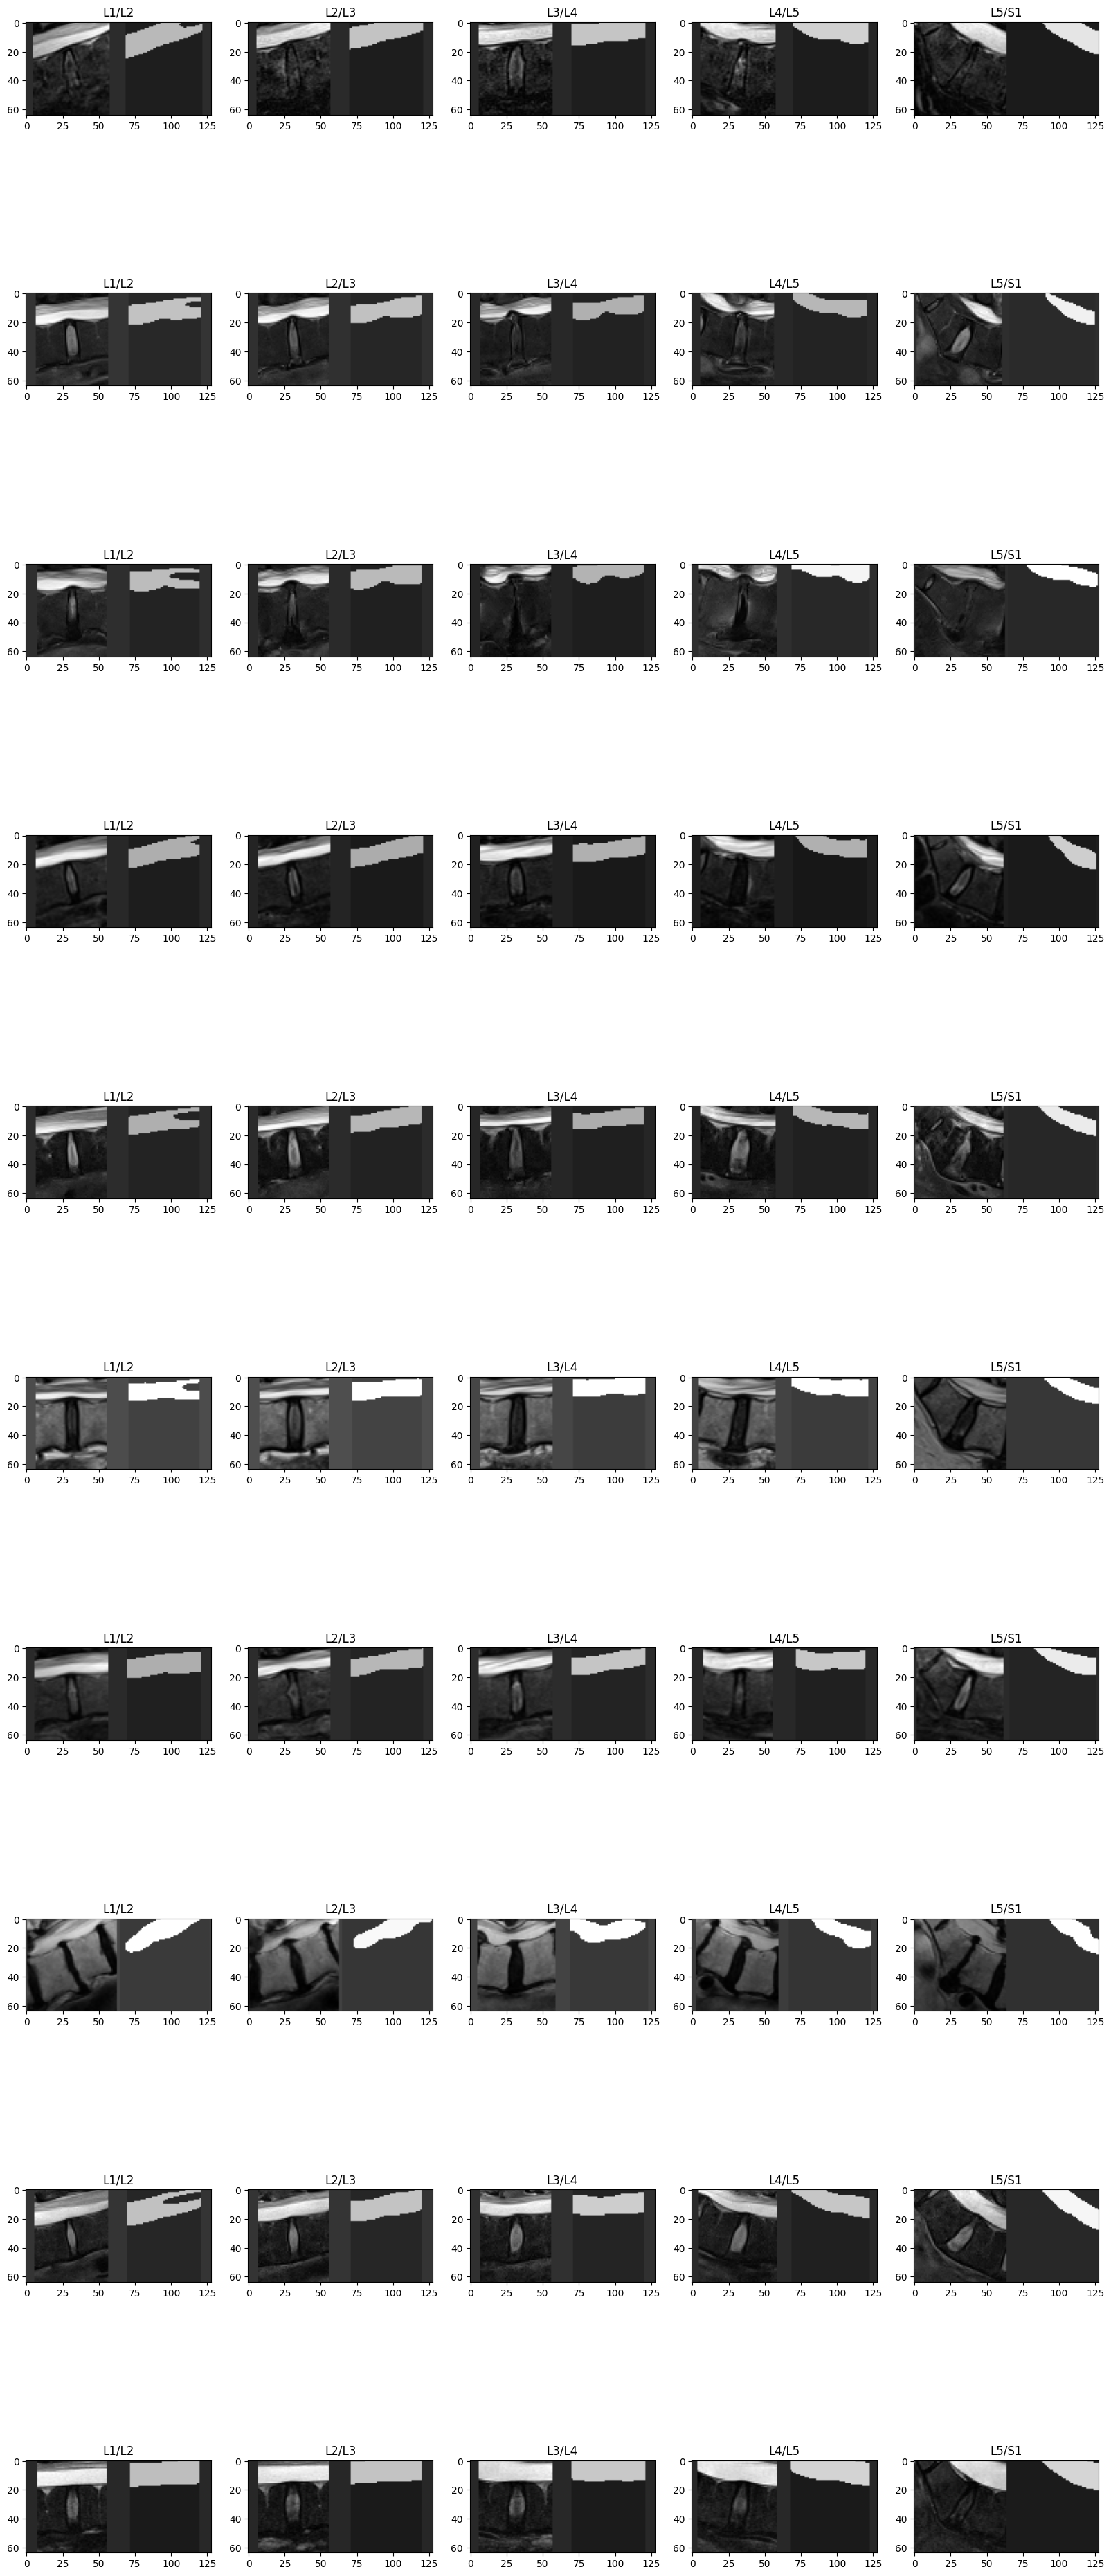

In [46]:
levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
fig, ax = plt.subplots(nrows=10, ncols=5, figsize=(20, 50))

for k in range(10):
    patches, patches_seg, label = dataset.__getitem__(np.random.randint(1354))
    print(label)
    for i, level in enumerate(levels):
        patch = patches[level]
        patch_seg = patches_seg[level]
        c, d, h, w = patch.shape
        ax[k, i].imshow(torch.cat((patch[0, d//2], patch_seg[0, d//2]), dim=1), cmap="gray")
        ax[k, i].set_title(levels[i])

In [47]:
loader = DataLoader(dataset)

In [48]:
_, _, label = next(iter(loader))

In [49]:
def patch_extraction2(vol, mask, d=2, h=20, w=20):
    """
    Extract a ROI from a volume with a given segmentation mask.

    vol : array of shape (D, H, W)
    mask : segmentation mask of shape (D, H, W)
    d, h, w : margin for each image axis
    """
    
    D, H, W = vol.shape
    mask = torch.Tensor(mask)
    nonzero_indices = torch.nonzero(mask)  # Extracting non-zero indices from the first channel

    d_min, h_min, w_min = nonzero_indices.min(0)[0]  # Minimum indices
    d_max, h_max, w_max = nonzero_indices.max(0)[0]  # Maximum indices
    
    patch1 = vol[max(0, d_min-d):min(D, d_min + d), 
                max(0, h_min - h):min(H, h_max + h), 
                max(0, w_min - w):min(W, w_max + w)]
    
    patch2 = vol[max(0, d_max-d):min(D, d_max + d), 
                max(0, h_min - h):min(H, h_max + h), 
                max(0, w_min - w):min(W, w_max + w)]

    return patch1, patch2

In [66]:
class ForaminalNarrowingDataset(Dataset):
    def __init__(self, 
                 vol_paths : list = None,
                 seg_paths : list = None,
                 labels_csv : str = "../data/train.csv",
                 transform : any = None):
        
        
        text2int = {"Normal/Mild": 0, "Moderate": 1, "Severe": 2}
        vol_paths.sort()
        seg_paths.sort()
        self.vol_paths = vol_paths
        self.seg_paths = seg_paths
        self.transform = transform
        
        self.labels = pd.read_csv(labels_csv)
        self.labels = self.labels[["study_id",
                                   "right_neural_foraminal_narrowing_l1_l2",
                                   "right_neural_foraminal_narrowing_l2_l3",
                                   "right_neural_foraminal_narrowing_l3_l4",
                                   "right_neural_foraminal_narrowing_l4_l5",
                                   "right_neural_foraminal_narrowing_l5_s1",
                                   "left_neural_foraminal_narrowing_l1_l2",
                                   "left_neural_foraminal_narrowing_l2_l3",
                                   "left_neural_foraminal_narrowing_l3_l4",
                                   "left_neural_foraminal_narrowing_l4_l5",
                                   "left_neural_foraminal_narrowing_l5_s1"]]
        self.labels = self.labels.replace(text2int)
        
    def __len__(self):
        return len(self.vol_paths)
        
    def __getitem__(self, idx):
        
        vol_path = self.vol_paths[idx]
        x = vol_path.split("/")[-1]
        x = x[:-7]+"_0000.nii.gz"
        
        vol = nib.load(path+"/output/input/"+x).get_fdata()
        
        study_id = x.split("_")[0][4:]
        
        seg_path = self.seg_paths[idx]
        
        label = self.labels[self.labels["study_id"]==int(study_id)].values[0,1:].astype(int)
        
        vol = nib.load(path+"/output/input/"+x).get_fdata()
        seg = nib.load(seg_path).get_fdata()
        
        D, H, W = vol.shape
        discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
        disc_l5 = np.isin(seg, [202]).astype(int)
        disc_l4 = np.isin(seg, [203]).astype(int)
        disc_l3 = np.isin(seg, [204]).astype(int)
        disc_l2 = np.isin(seg, [205]).astype(int)
        disc_l1 = np.isin(seg, [206]).astype(int)
        spinal_canal = np.isin(seg, [201]).astype(int)

        discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
        levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
        patches = {}
        patches_seg = {}
        
        w = 20
        for i, disc in enumerate(discs):
            patch1, patch2 = patch_extraction2(vol, disc, d=2, h=40, w=20)
            patches[levels[i]] = torch.cat((torch.Tensor(patch1[None]), torch.Tensor(patch2[None])), dim=1)
                
        # if self.transform is not None:
        #     patches = self.transform(patches)
        
        return patches, label       

In [67]:
root_dir="../../TotalSpineSeg"
vol_paths = glob.glob(root_dir + "/data/sub*T1w.nii.gz")
seg_paths = glob.glob(root_dir+"/output/step2_output/*T1w.nii.gz")

vol_paths.sort()
seg_paths.sort()

# train_vols, val_vols, train_seg, val_seg = train_test_split(vol_paths, seg_paths, test_size=0.3)

dataset = ForaminalNarrowingDataset(vol_paths=vol_paths, seg_paths=seg_paths, transform=None)
len(dataset)

1942

[0 0 0 0 1 0 0 0 0 0]
[0 0 1 0 0 0 0 0 0 0]
[0 0 1 1 1 0 0 0 0 0]
[0 0 0 1 0 0 0 0 1 1]
[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 1]
[0 0 1 2 0 0 0 0 1 1]
[0 0 0 0 0 0 0 0 0 0]
[0 0 0 1 0 0 0 0 0 0]


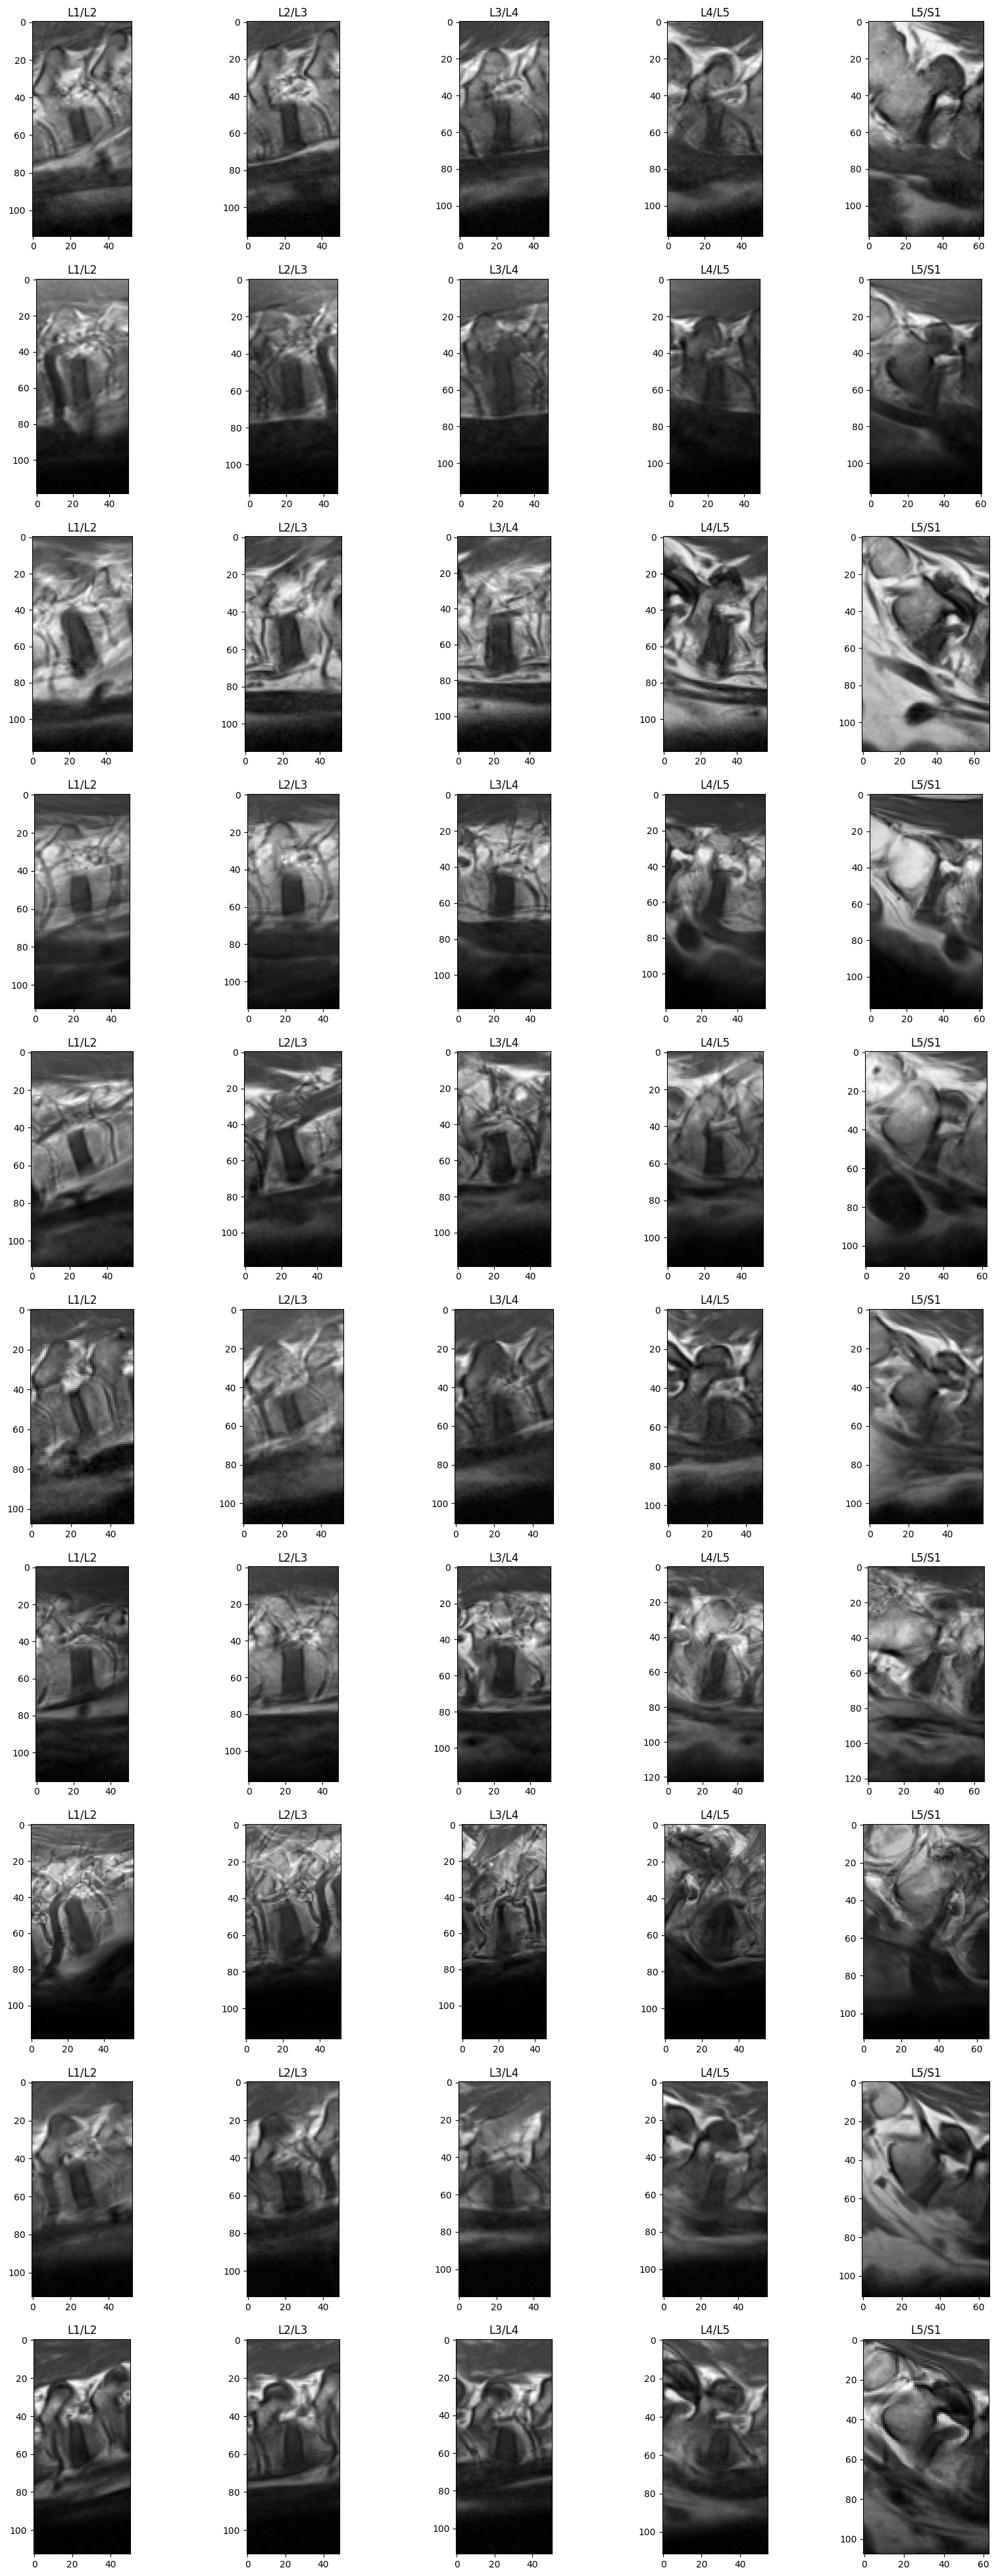

In [68]:
levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
fig, ax = plt.subplots(nrows=10, ncols=5, figsize=(20, 50))

for k in range(10):
    patches, label = dataset.__getitem__(np.random.randint(1354))
    print(label)
    for i, level in enumerate(levels):
        patch = patches[level]
        c, d, h, w = patch.shape
        ax[k, i].imshow(patch[0, d//2], cmap="gray")
        ax[k, i].set_title(levels[i])